<b>¡Hola Kevin!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b><a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.
¡Empecemos!

# Descripción del proyecto
Junto con el departamento de marketing de una gran tienda online se ha recopilado una lista de hipótesis que pueden ayudar a aumentar los ingresos, es necesario verificar los datos, realizar conjeturas, piorizar las hipótesis expuestas más adelante, lanzar un test A/B y analizar los resultados.

In [1]:
#Librerías importadas necesarias para la ejecución del proyecto
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

In [2]:
#Lectura de los archivos CSV y conversión a DataFrames
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
orders= pd.read_csv('/datasets/orders_us.csv')
visits= pd.read_csv('/datasets/visits_us.csv')

In [3]:
#Análisis exploratorio de los datos del DataFrame hypotheses
hypotheses.info()
#hypotheses.describe()
hypotheses

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


<div class="alert alert-block alert-success">
<b>Celda [3]</b> <a class="tocSkip"></a><br>
Buen uso de funciones estadísticas para obtener una visión inicial del conjunto de datos. Este tipo de análisis favorece la comprensión rápida del contexto.
</div>

In [4]:
#Análisis exploratorio de los datos del DataFrame orders
orders.info()
orders.describe()
orders.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


,transactionId,visitorId,date,revenue,group
1066,2241655654,3552142259,2019-08-11,90.5,B
1068,7210578,1495112755,2019-08-12,60.5,A
1166,2676541142,471551937,2019-08-14,55.2,B
730,3335803766,477780734,2019-08-30,115.3,A
313,1136317551,2416662824,2019-08-24,10.5,A
1073,3460288289,2993711540,2019-08-12,190.9,A
505,3896562897,3628338328,2019-08-06,40.2,B
286,3508803238,3117119809,2019-08-24,300.3,A
953,2932932798,3694317332,2019-08-28,140.2,B
982,3778147089,4243832526,2019-08-10,130.5,A


<div class="alert alert-block alert-warning">
<b>Celda [4]</b> <a class="tocSkip"></a><br>
Buen uso de <code>describe()</code> para el resumen estadístico. Podrías complementar esta revisión con visualizaciones como histogramas o boxplots, especialmente para la variable <code>revenue</code>, ya que detectar valores atípicos en los montos de pedidos puede ayudarte a decidir si necesitas limpiar los datos antes de un análisis más profundo. Esto es clave en experimentos A/B donde los outliers pueden distorsionar resultados.
</div>


In [5]:
#Análisis exploratorio de los datos del DataFrame visits
visits.info()
visits.describe()
visits.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


,date,group,visits
3,2019-08-04,A,717
9,2019-08-10,A,406
60,2019-08-30,B,490
10,2019-08-11,A,718
34,2019-08-04,B,770
33,2019-08-03,B,509
4,2019-08-05,A,756
2,2019-08-03,A,507
27,2019-08-28,A,594
17,2019-08-18,A,668


    - Dando un analisis rapido y amplio a los datos de los tres dataframes no se detectaron registros nulos ni duplicados, sin embargo se encontraron inconsistencias en los nombres de las series del DF HYPOTHESES que serán solo cambiados a minusculas para mantener el estándar de camelCase que tiene el resto.
    - Se cambiaran los tipos de datos de object a datetime de la serie llamada DATE presente en los DFs ORDERS y VISITS. 
    - Recordamos que existe una advertencia de que es posible que haya errores en los datasets originales de que algunos de los visitantes podrían haber entrado tanto en el grupo A como en el grupo B; para esto actualizaremos el DF ORDERS en la que eliminaremos los usuarios duplicados entre los dos grupos.
    - Existe la posibilidad de modificar el DF VISITS contando los usuarios de ORDERS sin duplicados, sin embargo esto alteraría la estructura de VISITS ya que no incluye a los usuarios que no compraron y no es posible identificarlos con facilidad.

In [6]:
#Cambiamos a minusculas los nombres de las columnas del dataframe hypotheses para mantener consistencia con el formato camelCase
hypotheses.columns = hypotheses.columns.str.lower()
hypotheses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


<div class="alert alert-block alert-success">
<b>Celda [6]</b> <a class="tocSkip"></a><br>
Excelente decisión al estandarizar los nombres de las columnas a minúsculas. Esto mejora la consistencia y facilita el manejo de los datos.
</div>

In [7]:
#Buscamos valores duplicados en el DataFrame orders
orders.duplicated().sum()

#Cambiamos el tipo de dato de la serie 'date' a datetime
orders['date'] = pd.to_datetime(orders['date'], format='%Y-%m-%d')

#Comprobamos el cambio de tipo de dato
orders.info()

#Verificamos si hay visitantes que aparecen en ambos grupos, dividimos en los grupos A y B el DF orders
users_a = set(orders[orders['group'] == 'A']['visitorId'])
users_b = set(orders[orders['group'] == 'B']['visitorId'])
duplicated_users = users_a & users_b
print("Usuarios presentes en ambos grupos:", len(duplicated_users))

#Eliminamos los usuarios duplicados para no sesgar los datos
if duplicated_users:
    orders = orders[~orders['visitorId'].isin(duplicated_users)]

#Verificamos que no hay usuarios duplicados
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB
Usuarios presentes en ambos grupos: 58
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1016 non-null   int64         
 1   visitorId      1016 non-null   int64         
 2   date           1016 non-null   datetime64[ns]
 3   revenue        1016 non-null   float64       
 4  

<div class="alert alert-block alert-warning">
<b>Celda [7]</b> <a class="tocSkip"></a><br>
Excelente que hayas identificado y eliminado usuarios presentes en ambos grupos del test A/B, lo cual evita sesgos en los resultados. Te sugiero mostrar explícitamente cuántos usuarios fueron eliminados (con <code>len(duplicated_users)</code>) y calcular qué porcentaje representan sobre el total. Esto ayudará a valorar si su presencia era marginal o crítica.
</div>


In [8]:
#Buscamos valores duplicados en el DataFrame visits
visits.duplicated().sum()

#Cambiamos el tipo de dato de la serie 'date' a datetime
visits['date'] = pd.to_datetime(visits['date'], format='%Y-%m-%d')

## 1 - Priorizar hipótesis
El archivo hypotheses_us.csv contiene nueve hipótesis sobre cómo aumentar los ingresos de una tienda online con Reach, Impact, Confidence y Effort especificados para cada una.

Se realizarán la siguientes actividades:

### 1.1 - Aplicar el framework ICE para priorizar hipótesis. 
Ordenarlas en orden descendente de prioridad.

In [9]:
#Se aplicá la formula ICE sobre el DataFrame hypotheses, redondeando los resultados a 1 decimal
hypotheses['ICE'] = (hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']
hypotheses['ICE'] = hypotheses['ICE'].round(2)
#Imprimimos y ordenamos el DataFrame hypotheses por la columna ICE de forma descendente
display(hypotheses.sort_values(by='ICE', ascending=False))

,hypothesis,reach,impact,confidence,effort,ICE
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.20
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.33
7,Add a subscription form to all the main pages....,10,7,8,5,11.20
6,Show banners with current offers and sales on ...,5,3,8,3,8.00
2,Add product recommendation blocks to the store...,8,3,7,3,7.00
1,Launch your own delivery service. This will sh...,2,5,4,10,2.00
5,Add a customer review page. This will increase...,3,2,2,3,1.33
3,Change the category structure. This will incre...,8,3,3,8,1.12
4,Change the background color on the main page. ...,3,1,1,1,1.00


<div class="alert alert-block alert-success">
<b>Celda [9]</b> <a class="tocSkip"></a><br>
La implementación de la métrica ICE es una excelente manera de priorizar hipótesis basadas en impacto, confianza y esfuerzo. La decisión de redondear a un decimal también ayuda a la claridad en la presentación de resultados.
</div>

### 1.2 - Aplicar el framework RICE para priorizar hipótesis. 
Ordenarlas en orden descendente de prioridad.

In [10]:
#Se aplica la formula RICE sobre el DataFrame hypotheses
hypotheses['RICE'] = (hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']
#Dvidimos el resultado de RICE entre 10 para igualar la escala de ICE
hypotheses['RICE'] = hypotheses['RICE'] / 10
hypotheses['RICE'] = hypotheses['RICE'].round(2)
#Imprimimos y ordenamos el DataFrame hypotheses por la columna RICE de forma descendente
display(hypotheses.sort_values(by='RICE', ascending=False))

,hypothesis,reach,impact,confidence,effort,ICE,RICE
7,Add a subscription form to all the main pages....,10,7,8,5,11.20,11.20
2,Add product recommendation blocks to the store...,8,3,7,3,7.00,5.60
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.33,4.00
6,Show banners with current offers and sales on ...,5,3,8,3,8.00,4.00
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.20,1.62
3,Change the category structure. This will incre...,8,3,3,8,1.12,0.90
1,Launch your own delivery service. This will sh...,2,5,4,10,2.00,0.40
5,Add a customer review page. This will increase...,3,2,2,3,1.33,0.40
4,Change the background color on the main page. ...,3,1,1,1,1.00,0.30


<div class="alert alert-block alert-warning">
<b>Celda [10]</b> <a class="tocSkip"></a><br>
Detecto una oportunidad importante de mejora: al calcular RICE, no es necesario dividir entre 10, ya que solo estás utilizando la métrica para fines de comparación relativa. Esta operación no cambia el orden, pero puede generar confusión al interpretar valores. Recomiendo quitar esa división para mantener consistencia con la definición estándar de RICE.
</div>


### 1.3 - Mostrar cómo cambia la priorización de hipótesis cuando utilizas RICE en lugar de ICE. 
Proporcionar una explicación de los cambios.

<Figure size 600x600 with 0 Axes>

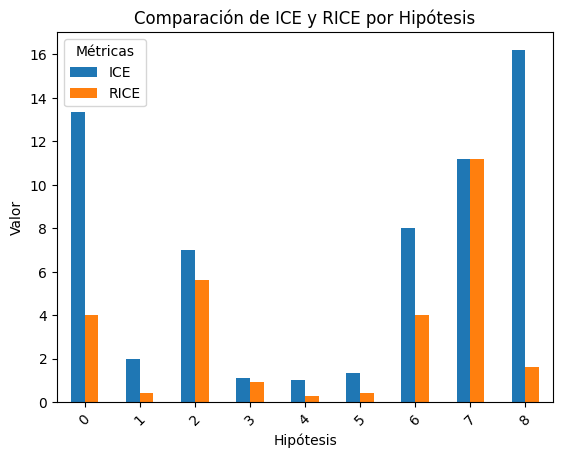

In [11]:
#Generamos un gráfico de barras comparativo de los valores de ICE y RICE de las hipótesis
plt.figure(figsize=(6, 6))
hypotheses.set_index(hypotheses.index)[['ICE', 'RICE']].plot(kind='bar', rot=45)
plt.title('Comparación de ICE y RICE por Hipótesis')
plt.xlabel('Hipótesis')
plt.ylabel('Valor')
plt.legend(title='Métricas')
plt.show()

<div class="alert alert-block alert-warning">
<b>Celda [11]</b> <a class="tocSkip"></a><br>
Buen uso del gráfico de barras para comparar las métricas ICE y RICE. Podrías enriquecer el análisis con una tabla adicional que muestre el <b>ranking de hipótesis en ambos métodos</b> y comentar por qué algunas hipótesis suben o bajan al incluir el "alcance" en RICE. Esto fortalece la interpretación estratégica del análisis.
</div>


    - Recordando que ICE es un framework que prioriza la velocidad en la toma de deciones, al solo prestar atención en el impacto y la confianza comparado con la facilidad (esfuerzo) de implementación. De esta forma nos muestra que las hipotesis con mejor calificación son la 8, 0 y 7, aún cuando las primeras dos no son de amplio alcance.
    - Mientras que RICE suma a esta ecuación el alcance por lo cual la nueva lista top 3 cambia a las hipótesis 7, 2 y 0; ahora se invierte la situación del alcance cuando los primeras 2 hipótesis son altas y la tercera es muy bajo.
    - En la gráfica es facil identificar las diferencias entre ambos frameworks y conocer que la hipotesis que muestra consistencia entre ambas es la número 7, por lo que se puede considerar como la de mayor prioridad.

## 2 - Parte 2. Análisis del test A/B

Se realizará el analisis del test A/B (los resultados del test son descritos en los archivos orders_us.csv y visits_us.csv) por medio de las siguientes acciones:

### 2.1 - Representa gráficamente el ingreso acumulado por grupo.
Haz conclusiones y conjeturas.

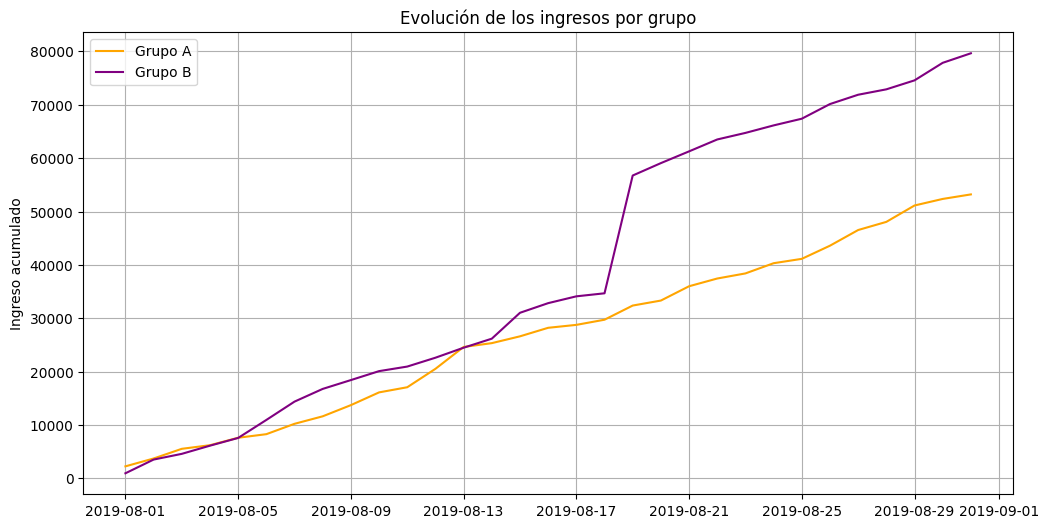

In [12]:
#Creamos una matriz con valores unicos de parejas fecha-grupo de la serie 'date' del DataFrame orders
datesGroups = orders[['date', 'group']].drop_duplicates()

#Calculamos el resultado de la prueba A/B para cada grupo y fecha, agregando los datos de las transacciones en un nuevo DataFrame *basandonos en el DF ORDERS
ordersAggregated = datesGroups.apply( 
    lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])].agg(
        {'date' : 'max', 'group' : 'max', 'transactionId' : pd.Series.nunique, 'visitorId' : pd.Series.nunique, 'revenue' : 'sum'}), axis=1
).sort_values(by=['date','group'])

#De forma similar, calculamos los datos diarios acumulados de visitas por grupo y fecha, basandonos en el DF VISITS
visitsAggregated = datesGroups.apply(
    lambda x: visits[np.logical_and(
        visits['date'] <= x['date'], visits['group'] == x['group']
    )].agg({'date' : 'max', 'group' : 'max', 'visits' : 'sum'}), axis=1
).sort_values(by=['date','group'])

#Fusionamos los DataFrames ordersAggregated y visitsAggregated en un nuevo DataFrame llamado cumulativeData
cumulativeData = ordersAggregated.merge(
    visitsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visits']

#Se creará una gráfica de líneas para visualizar la evolución del revenue de los grupos A y B a lo largo del tiempo
#Se separará el DF de ingresos acumulados en dos DataFrames, uno para cada grupo
cumulativeDataA = cumulativeData[cumulativeData['group'] == 'A']
cumulativeDataB = cumulativeData[cumulativeData['group'] == 'B']

plt.figure(figsize=(12, 6))
plt.plot(cumulativeDataA['date'], cumulativeDataA['revenue'], label='Grupo A', color='orange')
plt.plot(cumulativeDataB['date'], cumulativeDataB['revenue'], label='Grupo B', color='purple')
plt.title('Evolución de los ingresos por grupo')
plt.ylabel('Ingreso acumulado')
plt.legend()
plt.grid()
plt.show()

<div class="alert alert-block alert-success">
<b>Celda [12]</b> <a class="tocSkip"></a><br>
El cálculo de datos acumulados para las pruebas A/B está bien estructurado y permite una comparación clara entre los grupos. La preparación de los datos es un paso crítico que has manejado adecuadamente.
</div>

    - Comparando los grupos en cuanto a cómo evolucionan sus ingresos a lo largo del mes de agosto de 2019 podemos facilmente observar como durante los primeros 5 días del mes ambos grupos se comportan de forma similar, luego el grupo B se despega de A juntandose nuevamente hasta el día 13 para nuevamente separarse enormemente B sobre A.
    - Llama la atención del grupo B ese despunte de practicamente $20,000 ocurrido el día 19, este evento solo pasa una vez ya que despues de eso el comportamiento del grupo retoma el crecimiento constante marcado con anterioridad.

### 2.2 - Representa gráficamente el tamaño de pedido promedio acumulado por grupo. 
Haz conclusiones y conjeturas.

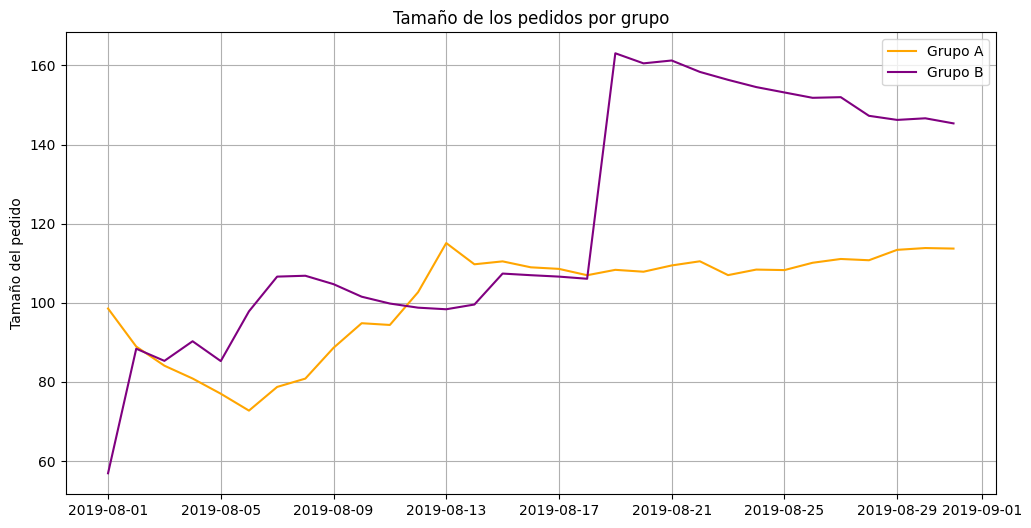

In [13]:
#Graficamos ahora el tamaño de los pedidos de cada grupo a lo largo del tiempo
plt.figure(figsize=(12, 6))
plt.plot(cumulativeDataA['date'], cumulativeDataA['revenue'] / cumulativeDataA['orders'], label='Grupo A', color='orange')
plt.plot(cumulativeDataB['date'], cumulativeDataB['revenue'] / cumulativeDataB['orders'], label='Grupo B', color='purple')
plt.title('Tamaño de los pedidos por grupo')
plt.ylabel('Tamaño del pedido')
plt.legend()
plt.grid()
plt.show()

<div class="alert alert-block alert-warning">
<b>Celda [13]</b> <a class="tocSkip"></a><br>
Has representado correctamente la evolución del tamaño promedio de pedido. Para fortalecer el análisis, podrías señalar si este comportamiento guarda relación con alguna hipótesis priorizada (por ejemplo, mostrar más recomendaciones aumenta el ticket promedio). Esto conectaría mejor el análisis gráfico con la toma de decisiones.
</div>


    - En este gráfico de "Tamaño de pedido por grupo" podemos observar y dar sustento al comportamiento registrado en la gráfica anterior, solo 2 veces el grupo A fue superior en esta metrica que B siendo particularmente alto del día 11 al 15.
    - Nuevamente observamos este fuerte despunte del grupo B el día 19 incrementando el tamaño del pedido por más de 40, pero a diferencia del gráfico anterior en la que el crecimiento se estabilizó aqui podemos ver como comienza a descender.

### 2.3 - Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A.
Haz conclusiones y conjeturas.

No handles with labels found to put in legend.


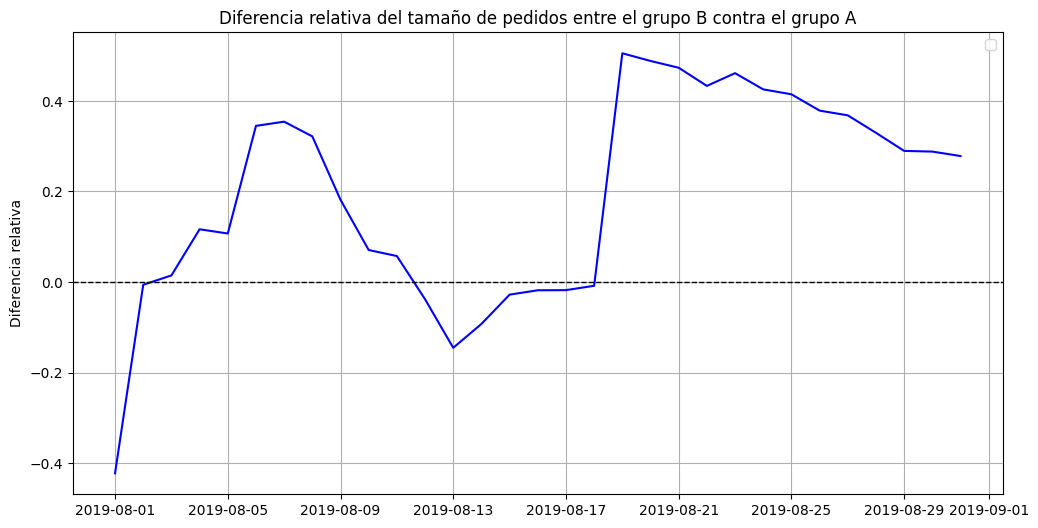

In [14]:
#Se trazará un gráfico de diferencia relativa de los tamaños promedios de compras del grupo B en comparación con el grupo A
#Primero dividimos el revenue acumulado por el número de pedidos para cada grupo
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

#Generamos el gráfico de línea de diferencia relativa del tamaño de pedidos entre los grupos
plt.figure(figsize=(12, 6))
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])
plt.plot(mergedCumulativeRevenue['date'], 
         (mergedCumulativeRevenue['revenueB'] / mergedCumulativeRevenue['ordersB']) / 
         (mergedCumulativeRevenue['revenueA'] / mergedCumulativeRevenue['ordersA']) - 1, color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Diferencia relativa del tamaño de pedidos entre el grupo B contra el grupo A')
plt.ylabel('Diferencia relativa')
plt.legend()
plt.grid()
plt.show()

    - La grafica de diferencia relativa muestra el comportamiento del tamaño del pedido del grupo B contra el grupo A; observando de forma rapida podemos ver la similitud de la gráfica actual con la anterior, lo que muestra la marcada diferencia de B contra A.
    - Lo que es más remarcable es que el pico presentado el día 19 ya no parece ser tan significativo si lo comparamos con los días 6 y 8 en los que la diferencia es poco más de 0.1.

### 2.4 - Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. 
Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. Saca conclusiones y haz conjeturas.

(18109.0, 18139.0, 0.0, 0.04)

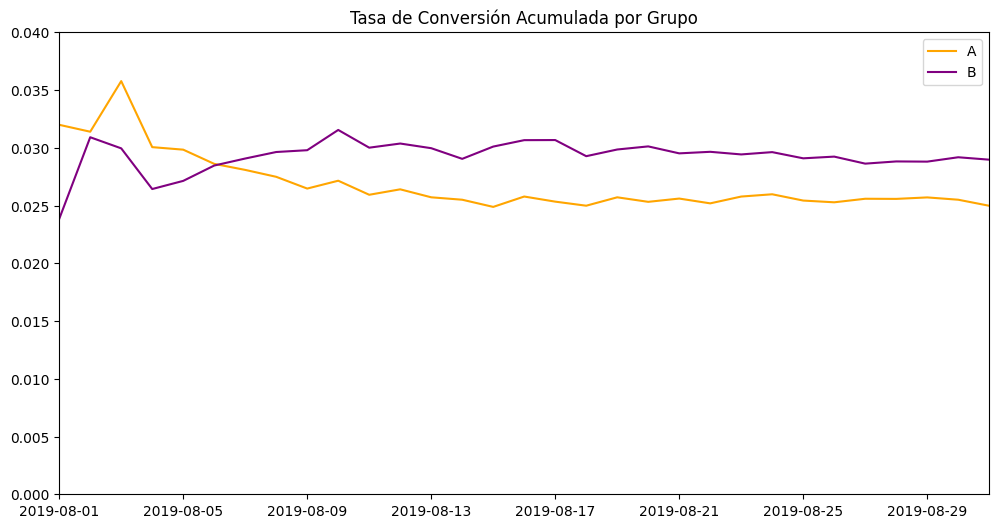

In [15]:
#Calculamos la tasa de conversión acumulada para cada grupo
cumulativeData['conversion'] = cumulativeData['orders'] / cumulativeData['visits']
#Dividimos el DataFrame en dos, uno para cada grupo
cumulativeDataA = cumulativeData[cumulativeData['group'] == 'A']
cumulativeDataB = cumulativeData[cumulativeData['group'] == 'B']

#Graficamos la tasa de conversión acumulada
plt.figure(figsize=(12, 6))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A', color='orange')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B', color='purple')
plt.title('Tasa de Conversión Acumulada por Grupo')
plt.legend()

# establecer la escala de los ejes
plt.axis([pd.to_datetime("2019-08-01"), pd.to_datetime('2019-08-31'), 0.0, 0.040])

    - El comportamiento de B nuevamente es superior al de A al estabilizarse la mayor parte del mes en el 30%, esto incluso si durante los primeros 5 días igualaba y descendia de esta cifra, aqui el día 18 que anteriormente era el foco de atención no es tan relevante.
    - El grupo A tiene un buen inicio e incluso el día 3 supera el máximo mensual de B, sin embargo a partir del día 5 que es cuanto B comienza su ascenso ocurre el efecto contrario en A y desciende al 25% de conversión.
    - Podemos suponer que el grupo B es practicamente contrario en su comportamiento el grupo A al observar las tendencias en el porcentaje de conversión y del tamaño de pedido.

### 2.5 - Traza un gráfico de dispersión del número de pedidos por usuario. 
Haz conclusiones y conjeturas.

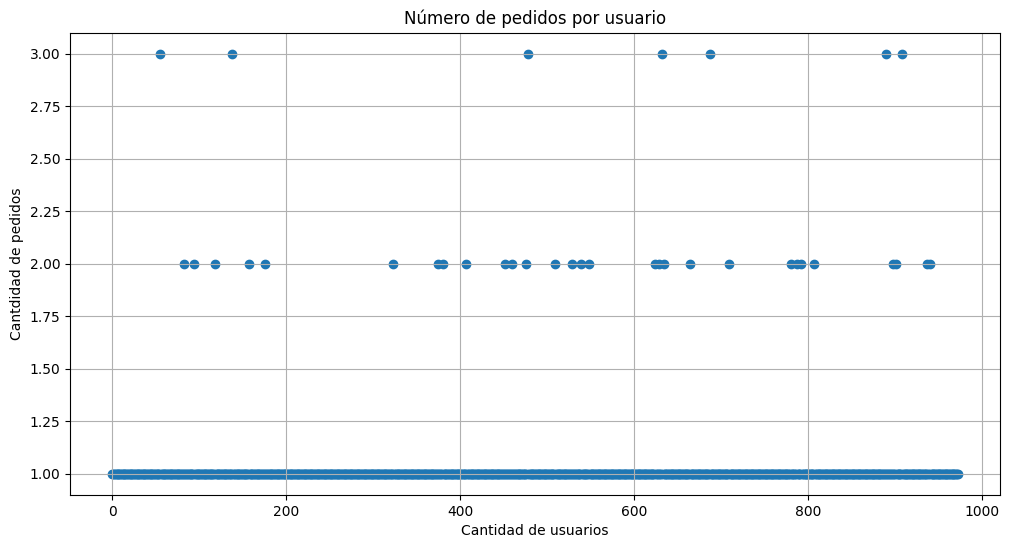

Usuarios con 1 pedido: 937
Usuarios con 2 pedidos: 36


In [16]:
#Generamos un gráfico de dispersión para visualizar el número de pedidos por usuario
ordersByUsers = orders.groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsers.columns = ['visitorId', 'orders']
x_values = pd.Series(range(0, len(ordersByUsers)))
plt.figure(figsize=(12, 6))
plt.scatter(x_values, ordersByUsers['orders'])
plt.title('Número de pedidos por usuario')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Cantdidad de pedidos')
plt.grid()
plt.show()

#Imprimimos cuantos usuarios realizaron 1, 2, 3 o más pedidos
print('Usuarios con 1 pedido:', ordersByUsers[ordersByUsers['orders'] == 1].shape[0])
print('Usuarios con 2 pedidos:', ordersByUsers[ordersByUsers['orders'] >= 2].shape[0])

<div class="alert alert-block alert-warning">
<b>Celda [16]</b> <a class="tocSkip"></a><br>
Buena visualización de la distribución de pedidos por usuario. Te recomiendo agregar líneas verticales indicando los percentiles 95 y 99. Esto permite identificar rápidamente outliers que pueden influir en el análisis estadístico, especialmente en métricas sensibles como conversión y ticket promedio.
</div>


    - Es facilmente apreciable que la mayoria de los usuarios solo realizaron 1 pedido, de ahí encontramos que en los 2 pedidos se concentra gran parte del restante de los usuarios y de 3 se vuelve muy esporadico y muy pocos usuarios realizaron esta cantidad de compras.
    - Al ver esto lo primero que nos viene a la mente es que solo el 3% de los usuarios realizan una recompra durante el mes y parece ser un punto debil en la estrategia de la empresa.

### 2.6 - Calcula los percentiles 95 y 99 del número de pedidos por usuario. 
Define el punto en el cual un punto de datos se convierte en una anomalía.

In [17]:
#Imprimimos los percentiles 95 y 99 del número de pedidos por usuario del dataframe ordersByUsers
#print(ordersByUsers['orders'].describe())
print("Percentil 95 de pedidos por usuario:", np.percentile(ordersByUsers['orders'], 95))
print("Percentil 99 de pedidos por usuario:", np.percentile(ordersByUsers['orders'], 99))

Percentil 95 de pedidos por usuario: 1.0
Percentil 99 de pedidos por usuario: 2.0


    - Reafirmamos el punto anterior de que el 95% del total de los usuarios se mantienen en el limite de solo 1 pedidos en promedio, el restante llega a realizar un máximo de 2 pedidos.
    - Para ciertas operaciones posteriores se considerará que cualquier usuario que iguale o supere los 2 pedidos caera en la clasificación de anómalos.

### 2.7 - Traza un gráfico de dispersión de los precios de los pedidos. 
Haz conclusiones y conjeturas.

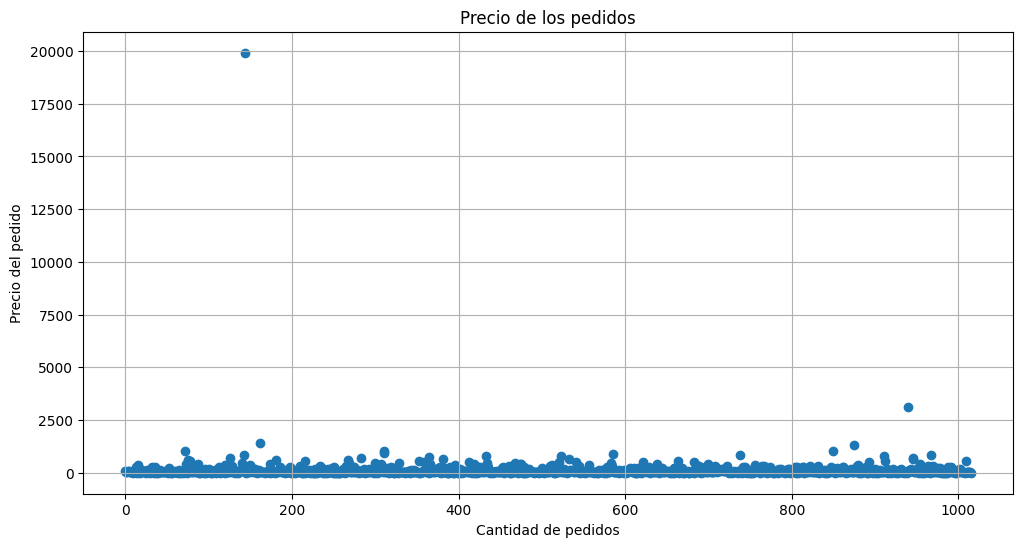

Precio del pedido más caro: 
      transactionId   visitorId       date  revenue group
425      590470918  1920142716 2019-08-19  19920.4     B


In [18]:
#Creamos un DataFrame con los ingresos por pedido, agrupando por transactionId
pricebyOrders = orders.groupby('transactionId', as_index=False).agg({'revenue' : 'sum'})
pricebyOrders.columns = ['transactionId', 'revenue']

#Generamos un gráfico de dispersión de los precios de los pedidos
plt.figure(figsize=(12, 6))
x_values = pd.Series(range(0, len(pricebyOrders['revenue'])))
plt.scatter(x_values, pricebyOrders['revenue'])
plt.title('Precio de los pedidos')
plt.xlabel('Cantidad de pedidos')
plt.ylabel('Precio del pedido')
plt.grid()
plt.show()

#Rastreamos el pedido particularmente más caro
print("Precio del pedido más caro:", '\n', orders[orders['revenue'] == orders['revenue'].max()])

    - Podemos identificar rapidamente en esta gráfica que practicamente todos los pedidos se encuentran por debajo del precio de $2,500 y encontramos solo 2 transacciones con pedidos de precio alto y llama particularmente la atención uno de ellos que es de cerca de $20,000 USD.
    - Si rastreamos este pedido tan alto encontramos que pertenece al grupo B por lo que ahora conocemos el porque en gráficas anteriores existía este despunte en revenue durante el día 19 de agosto.

### 2.8 - Calcula los percentiles 95 y 99 de los precios de los pedidos. 
Define el punto en el cual un punto de datos se convierte en una anomalía.

In [19]:
#Calculamos los percentiles 95 y 99 del precio de los pedidos
#print(pricebyOrders['revenue'].describe())
print("Percentil 95 del precio de los pedidos:", np.percentile(pricebyOrders['revenue'], 95))
print("Percentil 99 del precio de los pedidos:", np.percentile(pricebyOrders['revenue'], 99))

Percentil 95 del precio de los pedidos: 414.275
Percentil 99 del precio de los pedidos: 830.3


    - Al calcular los percentiles impacta conocer que la gráfica anterior es más engañosa que lo que parece ya que se apreciaban que los pedidos se encontraban mayoremente entre el rango de los $0 y los $2,500, sin embargo ahora conocemos que el 95% de los pedidos se encuentran en un máximo de $414.28, cualquier pedido superior a esta cifra será considerado como anómalo.
    - Para este punto ya conocemos los rangos que consideramos "normales" que son un revenue menor o igual a $414.28 y una cantidad de pedidos igual a 1.

### 2. 9- Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto.
Haz conclusiones y conjeturas.

In [20]:
#Dividimos el DataFrame ordersByUsers en dos, uno por cada grupo
ordersByUsersA = orders[orders['group'] == 'A'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersA.columns = ['visitorId', 'orders']
ordersByUsersB = orders[orders['group'] == 'B'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersB.columns = ['visitorId', 'orders']

#Creamos muestras con usuarios diferentes por cada grupo, los usuarios que no realizaron pedidos se asignarán a 0
sampleA = pd.concat(
    [ordersByUsersA['orders'],pd.Series(
        0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)
sampleB = pd.concat(
    [ordersByUsersB['orders'],pd.Series(
        0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)

#Obtenemos la importancia estadística de la diferencia entre los grupos A y B (*redondeado a 3 decimales) utilizando la prueba de Mann-Whitney
print("{0:.3f}".format(st.mannwhitneyu(sampleA, sampleB)[1]))
print("{0:.3f}".format(sampleB.mean()/sampleA.mean()-1))

0.011
0.160


<div class="alert alert-block alert-warning">
<b>Celda [20]</b> <a class="tocSkip"></a><br>
Muy bien al aplicar la prueba de Mann-Whitney, que es robusta ante distribuciones no normales. Para mejorar la claridad, podrías agregar una breve conclusión: si el p-valor < 0.05, entonces hay evidencia de diferencia en la conversión entre los grupos, lo cual es clave para la decisión final del experimento.
</div>


    - Al realizar la prueba Mann-Whitney a las muestras econtramos que SÍ existe una una diferencia estadistica ya que el valor P resulto menor a 0.05 por lo que podemos afirmar que "Podemos Rechazar la hipótesis nula".
    - El siguiente dato a analizar es el cambio relativo positivo de 16%, que reconoce esta diferencia de un mejor desempeño en el número de ordernes por ususario del grupo B contra A.

### 2.10 - Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto.
Haz conclusiones y conjeturas.

In [21]:
#Encontraremos la diferencia relativa en el tamaño promedio de pedido entre los grupos
print('{0:.3f}'.format(st.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]))
print('{0:.3f}'.format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1))

0.862
0.278


    - A diferencia de la prueba anterior ahora tenemos un valor P de 0.862 muy superior a 0.05 por lo que "NO podemos rechazar la hipótesis nula".
    - Cabe mencionar que nuevamente que el grupo B muestra un cambio relativo positivo del 27.8% sobre A.
    - En ambas pruebas de significancia las muestras incluian todos los datos lo que podría generarnos poca confianza sobre sus conclusiones, será necesario repetir estas pruebas pero eliminando los registros anomalos.

### 2.11 - Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados.
Haz conclusiones y conjeturas.

In [22]:
#filtraremos los usuarios para eliminar los datos anómalos
#Crearemos un DF filtrado para los pedidios promedios por usuario el percentil 95= 1 pedido, y el percentil 99= 2 pedidos 
usersWithManyOrders = pd.concat(
    [ordersByUsersA[ordersByUsersA['orders'] > 1]['visitorId'], 
     ordersByUsersB[ordersByUsersB['orders'] > 1]['visitorId']], axis=0)

#Para el tamaño promedio de pedido, el percentil 95= 414.28 y el percentil 99= 830.30, igual creamos un DF filtrado
usersWithExpensiveOrders = pd.concat(
    [orders[(orders['group']=='A') & (orders['revenue'] > 414.28)]['visitorId'], 
     orders[(orders['group']=='B') & (orders['revenue'] > 414.28)]['visitorId']], axis=0)

#Unimos los dos DataFrames filtrados para obtener los usuarios considerados anómalos
abnormalUsers = pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0).drop_duplicates().sort_values()

#Generamos muestras de usuarios filtrados para los grupos A y B
sampleFilteredA = pd.concat(
    [ordersByUsersA[np.logical_not(ordersByUsersA['visitorId'].isin(abnormalUsers))]['orders'], 
     pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])), name='orders')], axis=0)
sampleFilteredB = pd.concat(
    [ordersByUsersB[np.logical_not(ordersByUsersB['visitorId'].isin(abnormalUsers))]['orders'], 
     pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])), name='orders')], axis=0)

#Aplicamos la prueba de Mann-Whitney a las muestras filtradas
print("{0:.3f}".format(st.mannwhitneyu(sampleFilteredA, sampleFilteredB)[1]))
print("{0:.3f}".format(sampleFilteredB.mean()/sampleFilteredA.mean()-1))


0.016
0.174


    - Esta vez aplicamos el test Mann-Whitney U a las muestras filtradas (*eliminando los datos considerados anomalos pero manteniendo los usuarios que hicieron 0 pedidos) por grupos, y al obtener un valor P de 0.016 aún menor que en la prueba anterior (0.011) queda más que confirmado que SÍ existe esta diferencia significativa y "Podemos rechazar la hipótesis nula".
    - Igualmente el cambio relativo es positivo y sube de 16% a un 17.4%, quedando más que claro esta superioridad en las ordenes por usuario del grupo B sobre A.

### 2.12 - Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados.
Haz conclusiones y conjeturas.

In [23]:
print("{0:.3f}".format(st.mannwhitneyu(
    orders[np.logical_and(
        orders['group']=='A',  # Selecciona datos en el grupo A
        np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'],  # Excluye los usuarios anormales y selecciona los datos de ingreso para el grupo A
    orders[np.logical_and(
        orders['group']=='B',  # Selecciona datos en el grupo B
        np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue']  # Excluye los usuarios anormales y selecciona los datos de ingreso para el grupo B
)[1]))  # Extrae el valor p de los resultados de la prueba

# Muestra la diferencia relativa en el ingreso medio entre los grupos B y A
print("{0:.3f}".format(
    orders[np.logical_and(orders['group']=='B',  # Selecciona datos en el grupo B
           np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'].mean() /  # Calcula el ingreso medio para el grupo B
    orders[np.logical_and(orders['group']=='A',  # Selecciona datos en el grupo A
           np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue'].mean() - 1))  # Calcula el ingreso medio para el grupo A y muestra la diferencia relativa 

0.771
-0.033


    - En este nuevo test el valor P incrementa de 0.862 a 0.798 que continua siendo superior al valor alpha de 0.05, lo que refuerza el hecho de que las muestras NO son significativamente diferentes y por ende "NO podemos rechazar la hipótesis nula".
    - Curiosamente de todas las pruebas el único resultado distinto es sobre el cambio relativo que de ser un 27.8% se invierte a una cifra de -2.2%, sin embargo este cambio hace que la diferencia entre grupos por el gasto promedio por pedido entre grupos sea irrelevante en la práctica y en lo estadístico.

### 2.13 - Toma una decisión basada en los resultados de la prueba. 
Las decisiones posibles son: 
1. Parar la prueba, considerar a uno de los grupos como líder. 
2. Parar la prueba, concluir que no hay diferencia entre los grupos. 
3. Continuar la prueba.

    - Enfoncandonos en la cantidad de pedidos por usuario en ambos tests de Mann-Whitney U encontramos que el valor P es mucho menor a alpha "rechazando la hipótesis nula" y la diferencia realtiva es positiva por más de del 13% por lo que podemos reafirmar un mejor desempeño en la frecuncia de converisón del grupo B.
    - Para el valor promedio por pedido encontramos en ambos tests un valor P mayor que alpha por lo que no podemos encontrar una diferencia significativa entre las muestras y por ende "NO rechazando la hipótesis nula"; lo que llama la atención es en el cambio relativo que de ser positivo cambia a un valor negativo del -1.9% al eliminar los datos anómalos de las muestras, que al ser tan cercana a 0 podemos argumentar que no afecta mucho a la diferencia entre los grupos.
    - La decision que se toma es la número 1 de parar la prueba al considerar a B como el grupo líder, esto al tener un mucho mejor desempeño en la generación de pedidos y al tener practicamente una igualdad en los tamaños en promedio de los pedidos.

## Conclusiones

La primera etapa de nuestro proyecto desarrolla el aplicar el framework ICE y RICE sobre 9 hipótesis dirigidas a aumentar los ingresos de la tienda online de juguetes. En este aspecto tomaremos en cuenta las hipótesis con los resultados más altos tanto en ambos frameworks; las hipótesis con mayor prioridad para implementación incluyen: (7) agregar un formulario de suscripción en todas las páginas principales (RICE = 11.20), (2) añadir bloques de recomendación de productos para mejorar la conversión y el ticket promedio (RICE = 5.60), (0) lanzar dos nuevos canales de tráfico con alto impacto estimado (RICE = 4.00), y (6) mostrar banners de ofertas en la página principal (RICE = 4.00). Estas hipótesis destacan por su alto alcance, impacto potencial en la conversión y relativa facilidad de implementación, por lo que deberían priorizarse en los próximos ciclos de pruebas para maximizar el crecimiento con bajo costo de recursos.
Paralelamente, los resultados del experimento A/B muestran que el grupo B tiene un desempeño superior al grupo A en términos de cantidad de pedidos por usuario, con un aumento relativo entre 13.8% y 17.3% y una significancia estadística sólida (p < 0.05), incluso tras eliminar anomalías. En contraste, no se hallaron diferencias significativas en el tamaño promedio del pedido, lo que sugiere que los usuarios del grupo B no gastan más, pero sí compran con mayor frecuencia. Con base en estos resultados consistentes y robustos, se recomienda finalizar la prueba y adoptar al grupo B como la variante ganadora. Esta decisión, combinada con la ejecución de las hipótesis prioritarias según el RICE, puede generar un impacto positivo tangible tanto en la conversión como en la retención de usuarios.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Kevin! Has demostrado dominio en análisis de datos, visualización y pruebas estadísticas.<br><br>
✅ Tus fortalezas incluyen:<br>
• Limpieza consciente de datos (eliminación de usuarios duplicados y detección de outliers).<br>
• Aplicación correcta de ICE y RICE para priorización estratégica.<br>
• Uso apropiado de la prueba Mann-Whitney y análisis acumulativo.<br><br>

¡Felicidades por tu dedicación y pensamiento crítico!
</div>
